# Linear regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm
import statsmodels.formula.api as smf

      x     y
0  1995  39.7
1  1996  38.2
2  1997  34.7
3  1998  33.1
4  1999  30.1
5  2000  28.4
6  2001  26.3
7  2002  24.7


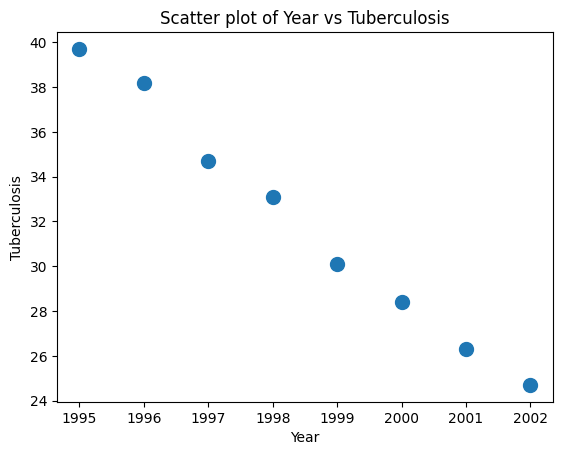

In [2]:
# Create DataFrame
x = range(1995, 2003)
y = [39.7, 38.2, 34.7, 33.1, 30.1, 28.4, 26.3, 24.7]
df = pd.DataFrame({'x': x, 'y': y})
print(df)

# Simple scatter plot
plt.scatter(df['x'], df['y'], s = 100);  # s is the marker size
plt.xlabel('Year');
plt.ylabel('Tuberculosis');
plt.title('Scatter plot of Year vs Tuberculosis');

In [3]:
model = smf.ols(formula = 'y ~ x', data = df).fit()
# print(model.summary())

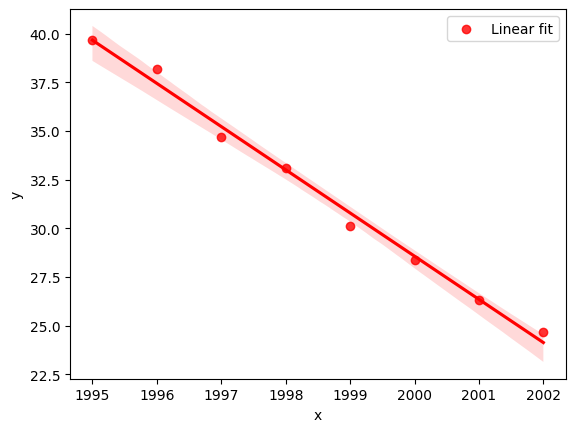

In [5]:
# Add regression line
sns.regplot(x = 'x',
            y = 'y',
            data = df,
            scatter = True,
            label = 'Linear fit',
            color = 'red')
plt.legend()
plt.show()

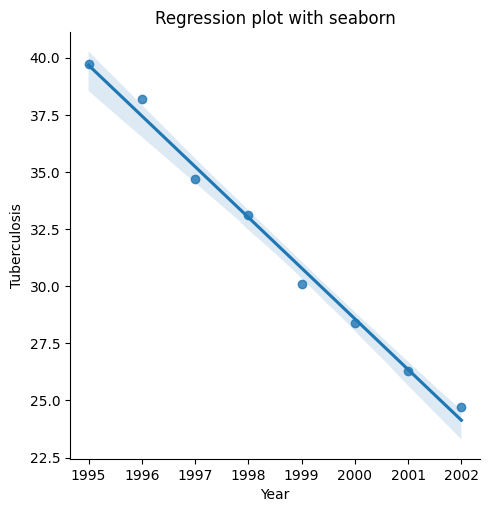

In [6]:
# Create a seaborn plot with linear fit
sns.lmplot(x='x', y='y', data=df)
plt.xlabel('Year')
plt.ylabel('Tuberculosis')
plt.title('Regression plot with seaborn')
plt.show()

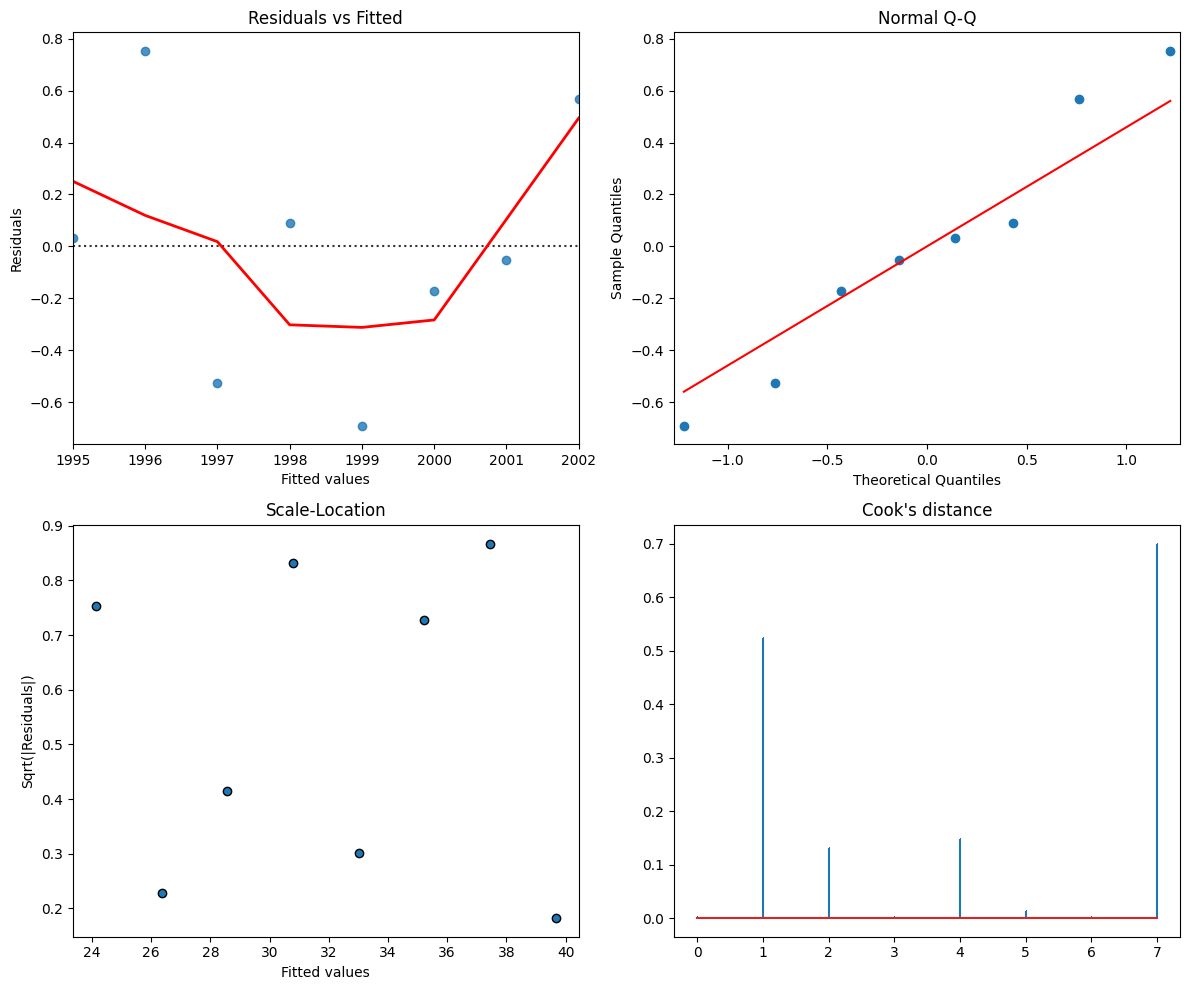

In [7]:
# Diagnostic plots
fig, ax = plt.subplots(2, 2, figsize = (12, 10))
sns.residplot(x='x', y='y', data=df, lowess=True, ax=ax[0, 0], line_kws={'color': 'red', 'lw': 2})
ax[0, 0].set_title('Residuals vs Fitted')
ax[0, 0].set_xlabel('Fitted values')
ax[0, 0].set_ylabel('Residuals')

# QQ plot
sm.qqplot(model.resid, line='s', ax=ax[0, 1])
ax[0, 1].set_title('Normal Q-Q')

# Scale-Location
ax[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), edgecolor='k')
ax[1, 0].set_title('Scale-Location')
ax[1, 0].set_xlabel('Fitted values')
ax[1, 0].set_ylabel('Sqrt(|Residuals|)')

# Cook's distance
from statsmodels.stats.outliers_influence import OLSInfluence
cd, _ = OLSInfluence(model).cooks_distance
ax[1, 1].stem(cd, markerfmt=',')
ax[1, 1].set_title("Cook's distance")
plt.tight_layout()
plt.show()

In [8]:
# Shapiro-Wilk normality test on residuals
w, p_value = shapiro(model.resid)
print(f'Shapiro-Wilk Test: W={w:.4f}, p-value={p_value:.4f}')

Shapiro-Wilk Test: W=0.9576, p-value=0.7866


In [9]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     736.5
Date:                Tue, 28 May 2024   Prob (F-statistic):           1.65e-07
Time:                        11:38:24   Log-Likelihood:                -5.1202
No. Observations:                   8   AIC:                             14.24
Df Residuals:                       6   BIC:                             14.40
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4466.6667    163.408     27.334      0.0

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [10]:
# Quality metrics
y_pred = model.predict()
y_true = df['y']

mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print({'MAE': mae, 'MAPE': mape, 'RMSE': rmse})

{'MAE': 0.3607142857142893, 'MAPE': 0.011551344975466431, 'RMSE': 0.4589065679365118}


# Exercice 1 (15 minutes)

Using the 'cars' dataset, create a scatter plot where the first variable is speed and the second is stopping distance. Fit a linear regression line to it and plot this line on the graph. Then, fit and plot a quadratic function.

The data give the speed of cars and the distances taken to stop. Note that the data were recorded in the 1920s.

1. Ezekiel, M. (1930) Methods of Correlation Analysis. Wiley.
2. McNeil, D. R. (1977) Interactive Data Analysis. Wiley.

# Multiple regression

   GNP.deflator      GNP  Unemployed  Armed.Forces  Population  Year  Employed
0          83.0  234.289       235.6         159.0     107.608  1947    60.323
1          88.5  259.426       232.5         145.6     108.632  1948    61.122
2          88.2  258.054       368.2         161.6     109.773  1949    60.171
3          89.5  284.599       335.1         165.0     110.929  1950    61.187
4          96.2  328.975       209.9         309.9     112.075  1951    63.221


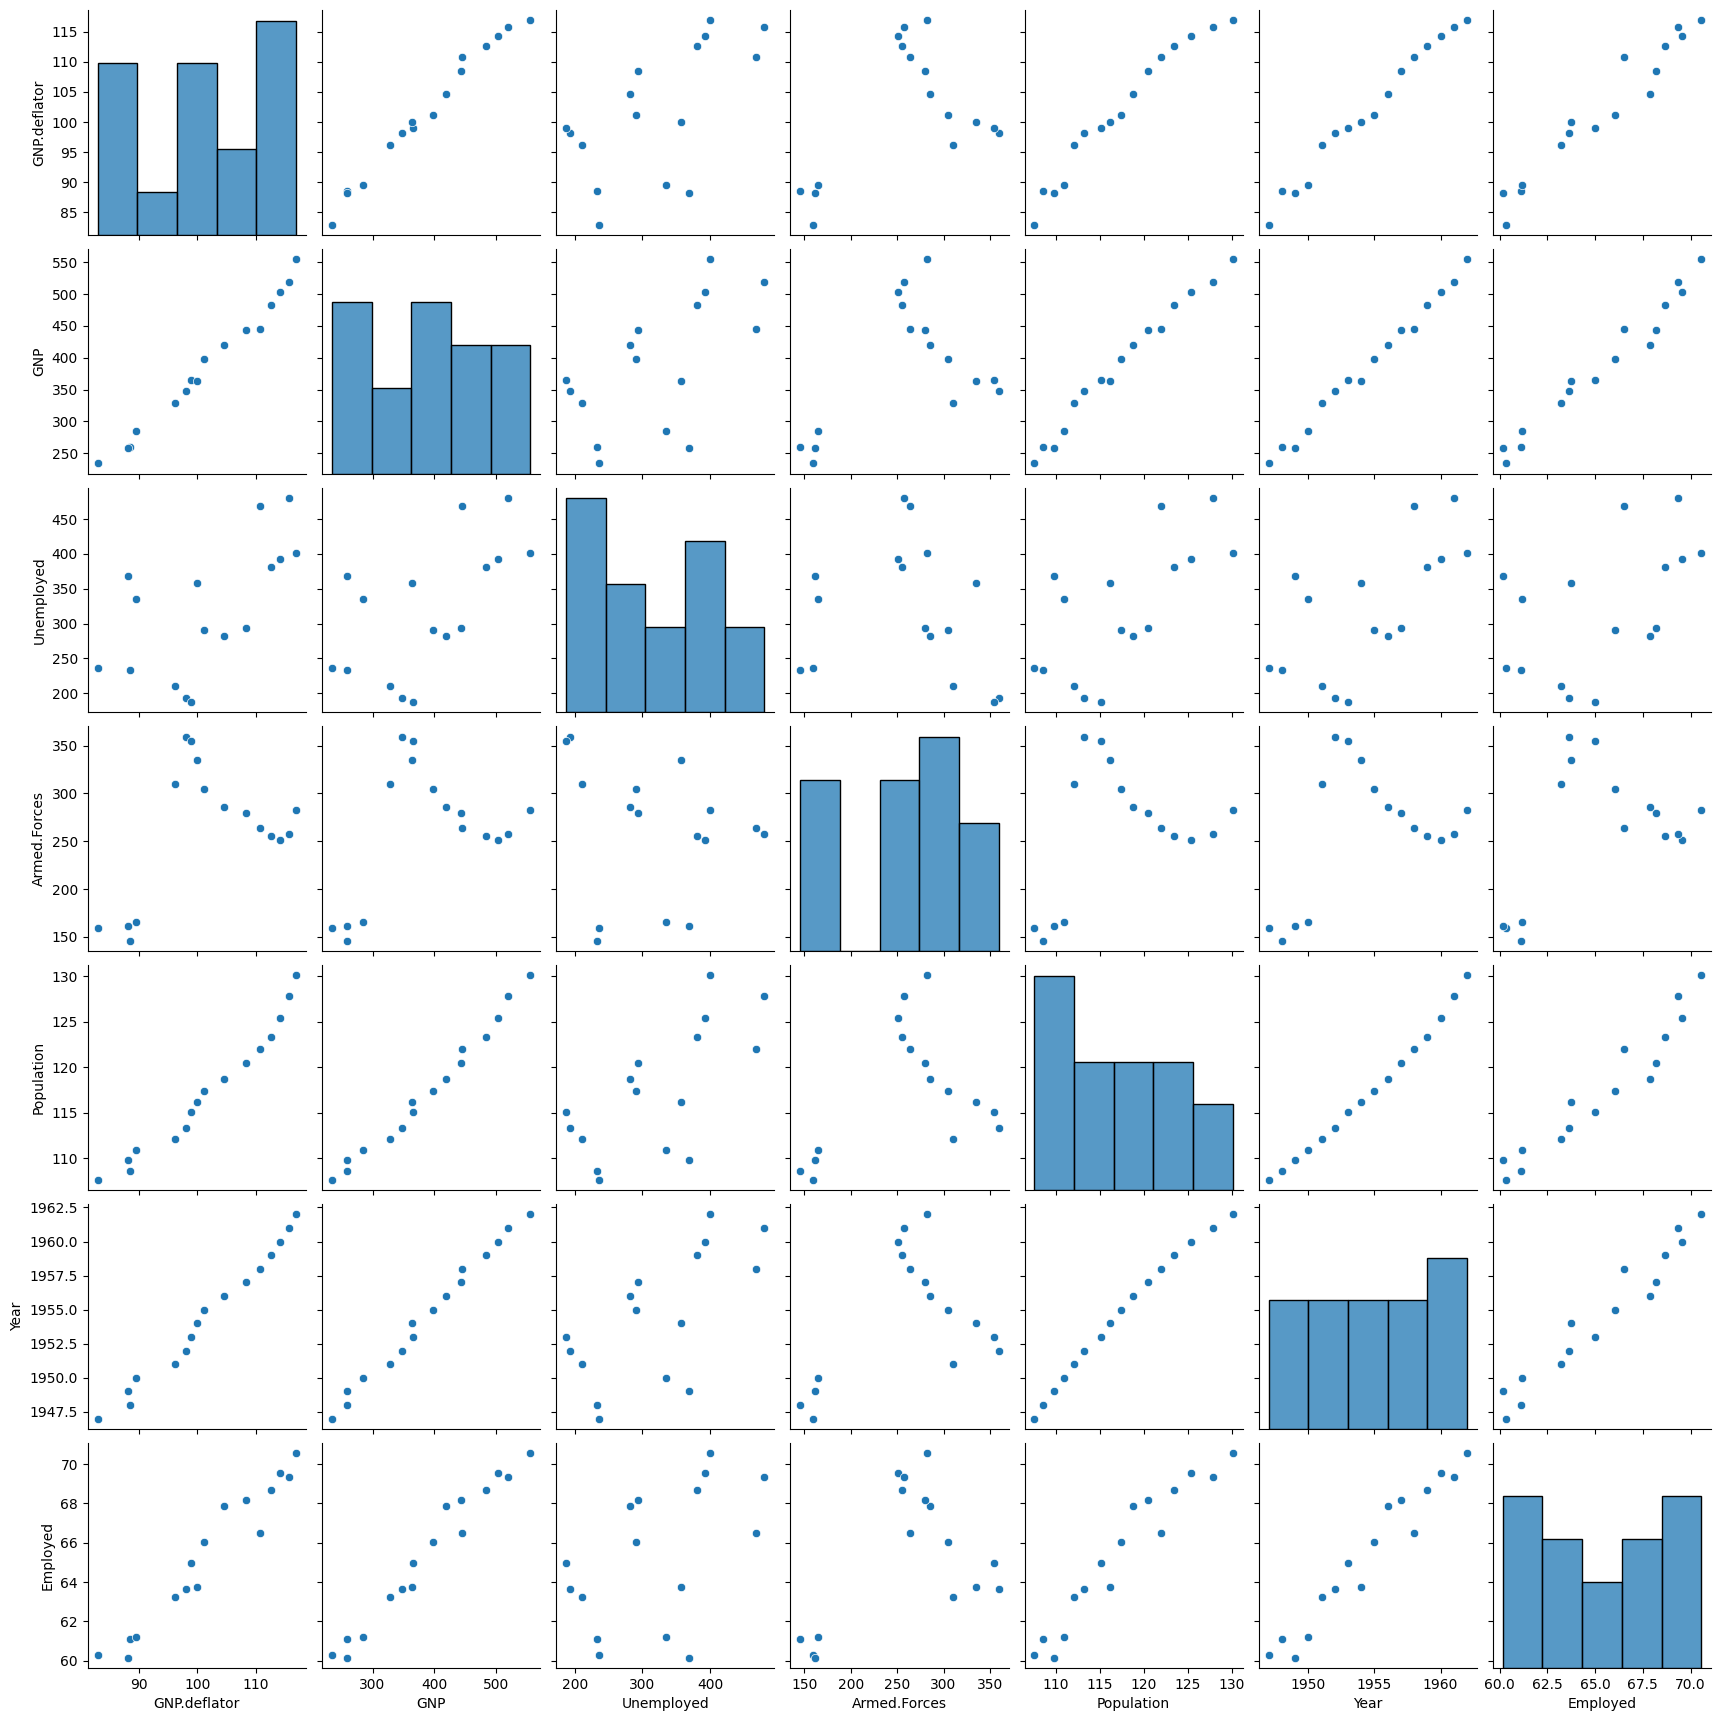

In [11]:
df = pd.read_csv('longley.csv')
print(df.head())

# Pairplot of the dataset
sns.pairplot(df)
plt.show()

In [12]:
# Linear regression model with all predictors
model1 = smf.ols('Employed ~ GNP + Population + Q("Armed.Forces") + Unemployed + Year',
                 data = df).fit()
print(model1.summary())

# Linear regression model with selected predictors
model2 = smf.ols('Employed ~ Unemployed + Q("Armed.Forces") + Year',
             data = df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               Employed   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     438.8
Date:                Tue, 28 May 2024   Prob (F-statistic):           2.24e-11
Time:                        12:11:48   Log-Likelihood:                0.87873
No. Observations:                  16   AIC:                             10.24
Df Residuals:                      10   BIC:                             14.88
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -3449.8916    828.24

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [13]:
# Define a function to calculate quality measures
def quality_measures(model, y_true):
    y_pred = model.predict()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': mae, 'RMSE': rmse}

# Calculate and display quality measures for all models
print("Quality measures for Model 1:", quality_measures(model1, df['Employed']))
print("Quality measures for Model 2:", quality_measures(model2, df['Employed']))

Quality measures for Model 1: {'MAE': 0.17608587102322248, 'RMSE': 0.22903984804327615}
Quality measures for Model 2: {'MAE': 0.2047030911149288, 'RMSE': 0.28759354377462476}


In [14]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
import pandas as pd

# Initialize a linear regression model
lr = LinearRegression()

X = df.drop('Employed', axis = 1)
y = df['Employed']  # Assuming 'Employed' is the target column
sfs = SequentialFeatureSelector(lr,
                                n_features_to_select = 3,
                                direction = 'backward')

sfs.fit(X, y)

# Print the selected features
print("Selected feature indices:", sfs.get_support(indices = True))
print("Selected feature names:", X.columns[sfs.get_support()])


Selected feature indices: [1 3 4]
Selected feature names: Index(['GNP', 'Armed.Forces', 'Population'], dtype='object')


In [ ]:
X.loc[:, sfs.get_support()]

In [16]:
model3 = smf.ols('Employed ~ GNP + Population + Q("Armed.Forces")',
                 data = df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:               Employed   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     238.6
Date:                Tue, 28 May 2024   Prob (F-statistic):           5.85e-11
Time:                        12:22:31   Log-Likelihood:                -9.4454
No. Observations:                  16   AIC:                             26.89
Df Residuals:                      12   BIC:                             29.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4710     17.09

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


# Logistic regression

In [24]:
# Create DataFrame
data = {
    'y': [1] * 10 + [0] * 10,
    'x1': [1] * 6 + [0] * 14,
    'x2': [70, 80, 50, 60, 40, 65, 75, 80, 70, 60, 65, 50, 45, 35, 40, 50, 55, 45, 50, 60]
}
df = pd.DataFrame(data)
print(df)

    y  x1  x2
0   1   1  70
1   1   1  80
2   1   1  50
3   1   1  60
4   1   1  40
5   1   1  65
6   1   0  75
7   1   0  80
8   1   0  70
9   1   0  60
10  0   0  65
11  0   0  50
12  0   0  45
13  0   0  35
14  0   0  40
15  0   0  50
16  0   0  55
17  0   0  45
18  0   0  50
19  0   0  60


In [25]:
# Full logistic regression model
model_logistic_full = smf.glm('y ~ x1 + x2',
                              data = df,
                              family = sm.families.Binomial()).fit()
print(model_logistic_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   20
Model:                            GLM   Df Residuals:                       17
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2.8949
Date:                Tue, 28 May 2024   Deviance:                       5.7899
Time:                        12:32:02   Pearson chi2:                     5.25
No. Iterations:                    21   Pseudo R-squ. (CS):             0.6661
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.2348     11.304     -1.702      0.0

In [26]:
# Reduced logistic regression model
model_logistic_reduced = smf.glm('y ~ x2',
                                 data = df,
                                 family = sm.families.Binomial()).fit()
print(model_logistic_reduced.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9.8003
Date:                Tue, 28 May 2024   Deviance:                       19.601
Time:                        12:32:49   Pearson chi2:                     19.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3339
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.0925      3.171     -2.237      0.0

In [27]:
# Odds ratios and confidence intervals
print(np.exp(model_logistic_reduced.params))  # Exponentiating the coefficients to get odds ratios
conf = model_logistic_reduced.conf_int()
conf = np.exp(conf)
conf.columns = ['2.5%', '97.5%']
print(conf)

Intercept    0.000831
x2           1.132734
dtype: float64
               2.5%     97.5%
Intercept  0.000002  0.415847
x2         1.016377  1.262413


In [29]:
# Prediction
pred_points = pd.DataFrame({'x2': [30, 80]})
pred_glm = model_logistic_reduced.predict(pred_points)
print("Predicted probabilities:\n", pred_glm)

Predicted probabilities:
 0    0.033782
1    0.946762
dtype: float64


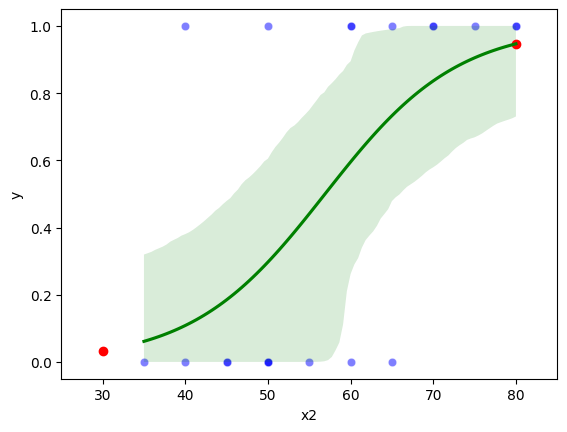

In [30]:
# Plot
sns.scatterplot(x = 'x2',
                y = 'y',
                data = df,
                color = 'blue',
                alpha = 0.5)
sns.regplot(x = 'x2',
            y = 'y',
            data = df,
            logistic = True,
            ci = 95,
            scatter = False,
            line_kws = {'color': 'green'})
plt.scatter([30, 80],
            pred_glm,
            color = 'red')  # Predicted points
plt.xlim(25, 85)
plt.show()

# Exercice 2 (15 minutes)

Prepare a logistic regression model to predict the probability of developing Type 2 Diabetes using the dataset 'patient.csv'. Add the predicted probabilities to the original dataframe. Plot a histogram of the predicted probabilities.